In [12]:
import sys
print(sys.executable)

C:\Users\Naol\Desktop\Unit project\FUTURE PROJECT\FUTURE_01\venv\Scripts\python.exe


In [13]:
import pandas as pd
print(pd.__version__)

3.0.3


In [11]:
import pandas as pd

train = pd.read_csv("../data/raw/train.csv")

train.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [14]:
import pandas as pd

train = pd.read_csv("../data/raw/train.csv")

train.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [7]:
train.shape

(3000888, 6)

In [15]:
train.columns

Index(['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion'], dtype='str')

In [9]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         str    
 2   store_nbr    int64  
 3   family       str    
 4   sales        float64
 5   onpromotion  int64  
dtypes: float64(1), int64(3), str(2)
memory usage: 137.4 MB


In [16]:
train['date'] = pd.to_datetime(train['date'])

In [17]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype         
---  ------       -----         
 0   id           int64         
 1   date         datetime64[us]
 2   store_nbr    int64         
 3   family       str           
 4   sales        float64       
 5   onpromotion  int64         
dtypes: datetime64[us](1), float64(1), int64(3), str(1)
memory usage: 137.4 MB


In [18]:
train['year'] = train['date'].dt.year
train['month'] = train['date'].dt.month
train['day'] = train['date'].dt.day
train['dayofweek'] = train['date'].dt.dayofweek

In [19]:
train.head()

,id,date,store_nbr,family,sales,onpromotion,year,month,day,dayofweek
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,2013,1,1,1
1,1,2013-01-01,1,BABY CARE,0.0,0,2013,1,1,1
2,2,2013-01-01,1,BEAUTY,0.0,0,2013,1,1,1
3,3,2013-01-01,1,BEVERAGES,0.0,0,2013,1,1,1
4,4,2013-01-01,1,BOOKS,0.0,0,2013,1,1,1


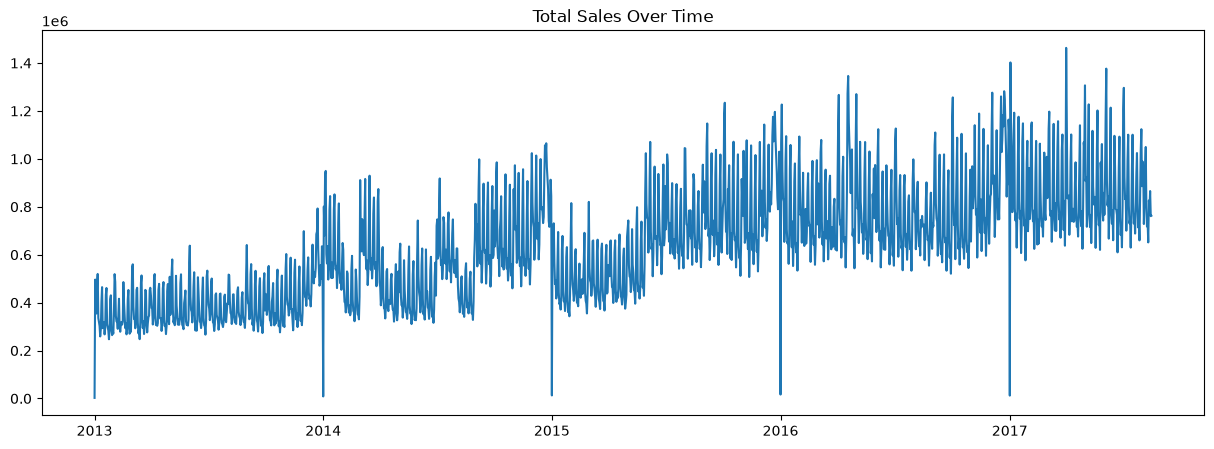

In [20]:
import matplotlib.pyplot as plt

daily_sales = train.groupby('date')['sales'].sum()

plt.figure(figsize=(15,5))
plt.plot(daily_sales)
plt.title("Total Sales Over Time")
plt.show()

<Axes: xlabel='month'>

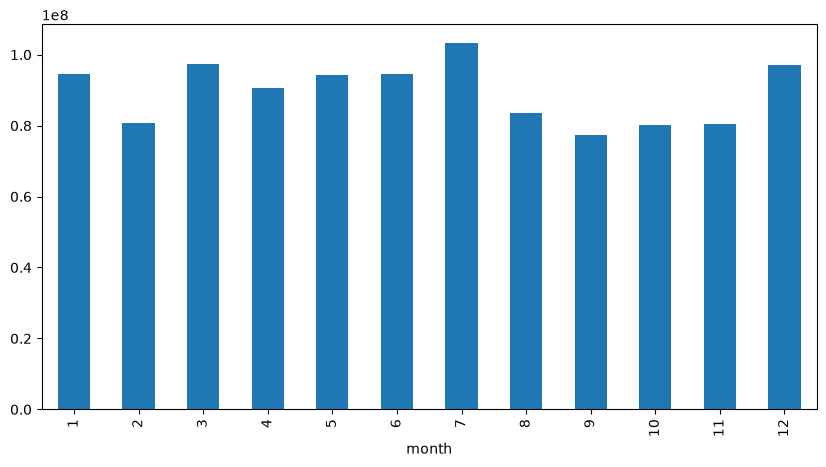

In [21]:
monthly_sales = train.groupby('month')['sales'].sum()

monthly_sales.plot(kind='bar', figsize=(10,5))

In [22]:
store_sales = train.groupby('store_nbr')['sales'].sum()

store_sales.sort_values(ascending=False).head(10)

store_nbr
44    6.208755e+07
45    5.449801e+07
47    5.094831e+07
3     5.048191e+07
49    4.342010e+07
46    4.189606e+07
48    3.593313e+07
51    3.291149e+07
8     3.049429e+07
50    2.865302e+07
Name: sales, dtype: float64

In [23]:
family_sales = train.groupby('family')['sales'].sum()

family_sales.sort_values(ascending=False)

family
GROCERY I                     3.434627e+08
BEVERAGES                     2.169545e+08
PRODUCE                       1.227047e+08
CLEANING                      9.752129e+07
DAIRY                         6.448771e+07
BREAD/BAKERY                  4.213395e+07
POULTRY                       3.187600e+07
MEATS                         3.108647e+07
PERSONAL CARE                 2.459205e+07
DELI                          2.411032e+07
HOME CARE                     1.602274e+07
EGGS                          1.558830e+07
FROZEN FOODS                  1.407389e+07
PREPARED FOODS                8.799895e+06
LIQUOR,WINE,BEER              7.746640e+06
SEAFOOD                       2.015432e+06
GROCERY II                    1.962767e+06
HOME AND KITCHEN I            1.861491e+06
HOME AND KITCHEN II           1.520670e+06
CELEBRATION                   7.611770e+05
LINGERIE                      6.531140e+05
LADIESWEAR                    6.511590e+05
PLAYERS AND ELECTRONICS       5.626080e+05
AUTO

In [26]:
store_family = train.groupby(['store_nbr', 'family'])['sales'].sum()

store_family.sort_values(ascending=False).head(10)

store_nbr  family   
44         GROCERY I    1.638606e+07
45         GROCERY I    1.634975e+07
47         GROCERY I    1.551453e+07
46         GROCERY I    1.434226e+07
44         BEVERAGES    1.341786e+07
3          GROCERY I    1.297047e+07
48         GROCERY I    1.283099e+07
45         BEVERAGES    1.137035e+07
3          BEVERAGES    1.135159e+07
49         GROCERY I    1.108798e+07
Name: sales, dtype: float64

In [29]:
promo_sales = train.groupby('onpromotion')['sales'].mean()

promo_sales

onpromotion
0       158.246681
1       467.556532
2       662.925632
3       871.408092
4       969.916135
          ...     
719    6681.000000
720    6154.000000
722    5846.000000
726    6044.000000
741    7517.000000
Name: sales, Length: 362, dtype: float64

In [30]:
train.groupby('onpromotion')['sales'].mean()

onpromotion
0       158.246681
1       467.556532
2       662.925632
3       871.408092
4       969.916135
          ...     
719    6681.000000
720    6154.000000
722    5846.000000
726    6044.000000
741    7517.000000
Name: sales, Length: 362, dtype: float64

In [31]:
train['promo_flag'] = train['onpromotion'] > 0

train.groupby('promo_flag')['sales'].mean()

promo_flag
False     158.246681
True     1137.693730
Name: sales, dtype: float64

In [32]:
features = train[['store_nbr', 'onpromotion', 'year', 'month', 'dayofweek']]
target = train['sales']

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=50, random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of

In [36]:
# Check your minimum and maximum dates to understand your timeline
print("Start date:", train['date'].min())
print("End date:", train['date'].max())

# Let's hold out the last few months of your data for testing.
# For example, if your data ends in August 2017, we can split at 2017-06-01.
split_date = '2017-06-01' 

# Create Train and Test sets based on time
train_set = train[train['date'] < split_date]
test_set = train[train['date'] >= split_date]

# Define your features (X) and target (y) for both sets
feature_cols = ['store_nbr', 'onpromotion', 'year', 'month', 'dayofweek']

X_train = train_set[feature_cols]
y_train = train_set['sales']

X_test = test_set[feature_cols]
y_test = test_set['sales']

print(f"Train shapes: X={X_train.shape}, y={y_train.shape}")
print(f"Test shapes: X={X_test.shape}, y={y_test.shape}")

Start date: 2013-01-01 00:00:00
End date: 2017-08-15 00:00:00
Train shapes: X=(2865456, 5), y=(2865456,)
Test shapes: X=(135432, 5), y=(135432,)


In [37]:
from sklearn.ensemble import RandomForestRegressor
import numpy as np

print("Training the Random Forest model... (This might take a minute depending on data size)")

# Initialize the model
# n_estimators=50 uses 50 trees to keep it faster for your first run; n_jobs=-1 uses all CPU cores
model = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)

# Train the model
model.fit(X_train, y_train)

print("Model trained successfully!")

Training the Random Forest model... (This might take a minute depending on data size)
Model trained successfully!


In [38]:
# Predict sales for the test period
y_pred = model.predict(X_test)

In [39]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("--- Model Evaluation ---")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score (Goodness of Fit): {r2:.4f}")

--- Model Evaluation ---
Mean Absolute Error (MAE): 338.43
Root Mean Squared Error (RMSE): 909.10
R² Score (Goodness of Fit): 0.5346


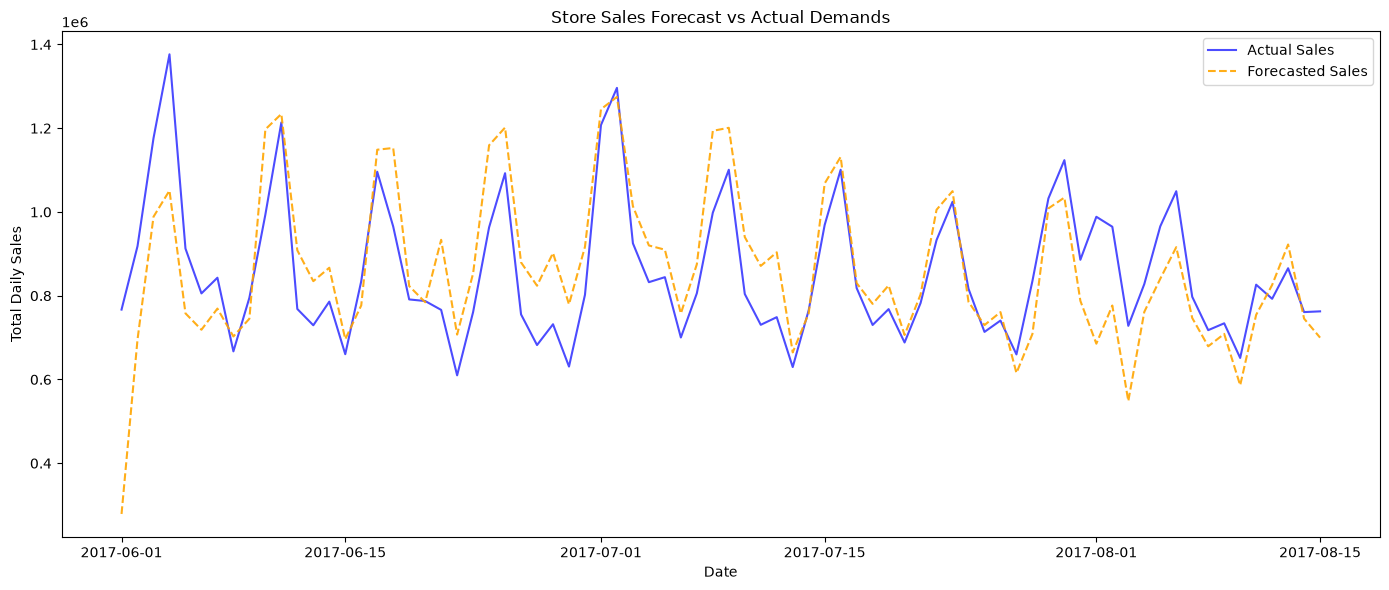

In [40]:
import matplotlib.pyplot as plt

# Group the actual test sales and predicted sales by date for a clean line chart
test_results = test_set.copy()
test_results['predicted_sales'] = y_pred

# Group by the original date index to see daily totals
daily_actual = test_results.groupby('date')['sales'].sum()
daily_pred = test_results.groupby('date')['predicted_sales'].sum()

# Plot actual vs predicted sales
plt.figure(figsize=(14, 6))
plt.plot(daily_actual.index, daily_actual.values, label='Actual Sales', color='blue', alpha=0.7)
plt.plot(daily_pred.index, daily_pred.values, label='Forecasted Sales', color='orange', linestyle='--', alpha=0.9)

plt.title('Store Sales Forecast vs Actual Demands')
plt.xlabel('Date')
plt.ylabel('Total Daily Sales')
plt.legend()
plt.tight_layout()

# Save it directly to your charts folder as required by your project spec
plt.savefig('../outputs/charts/forecast_vs_actual.png')
plt.show()

In [41]:
# Import your own custom engineering pipeline scripts
import sys
sys.path.append('../src')

from preprocess import load_and_preprocess_data
from features import split_features_and_target
from model import train_random_forest, evaluate_predictions
from visualize import plot_and_save_forecast

# 1. Run Pipeline
df_clean = load_and_preprocess_data("../data/raw/train.csv")
X_train, y_train, X_test, y_test, test_subset = split_features_and_target(df_clean)

# 2. Train and Predict
trained_model = train_random_forest(X_train, y_train)
predictions = trained_model.predict(X_test)

# 3. Score and Render Deliverables
evaluate_predictions(y_test, predictions)
plot_and_save_forecast(test_subset, predictions)

Training Random Forest via script engine...

--- Script Performance Metrics ---
MAE: 338.43
RMSE: 909.10
R² Score: 0.5346
Production visualization saved successfully to: ../outputs/charts/forecast_vs_actual.png


In [42]:
import pandas as pd

# Combine the date, store, and predicted sales into a clean dataframe
export_df = pd.DataFrame({
    'date': test_subset['date'],
    'store_nbr': test_subset['store_nbr'],
    'family': test_subset.get('family', 'All'), # Includes product family if available
    'actual_sales': y_test,
    'forecasted_sales': predictions
})

# Save the predictions to the forecasts directory
export_path = '../outputs/forecasts/final_sales_forecast.csv'
export_df.to_csv(export_path, index=False)

print(f"✅ Success! Predictions exported for business reporting to: {export_path}")

✅ Success! Predictions exported for business reporting to: ../outputs/forecasts/final_sales_forecast.csv
